IRIS DATASET
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape:
(150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Dataset after preprocessing:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4            

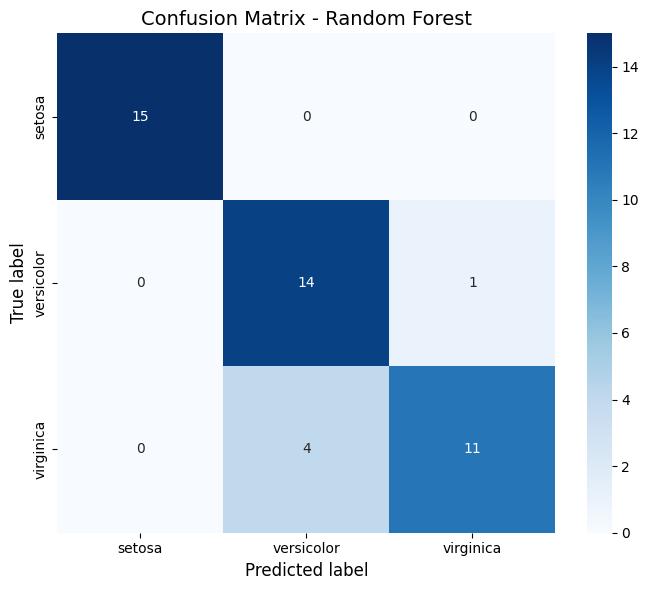


FEATURE IMPORTANCE
             Feature  Importance
1   sepal width (cm)    0.024273
0  sepal length (cm)    0.120608
2  petal length (cm)    0.400227
3   petal width (cm)    0.454892


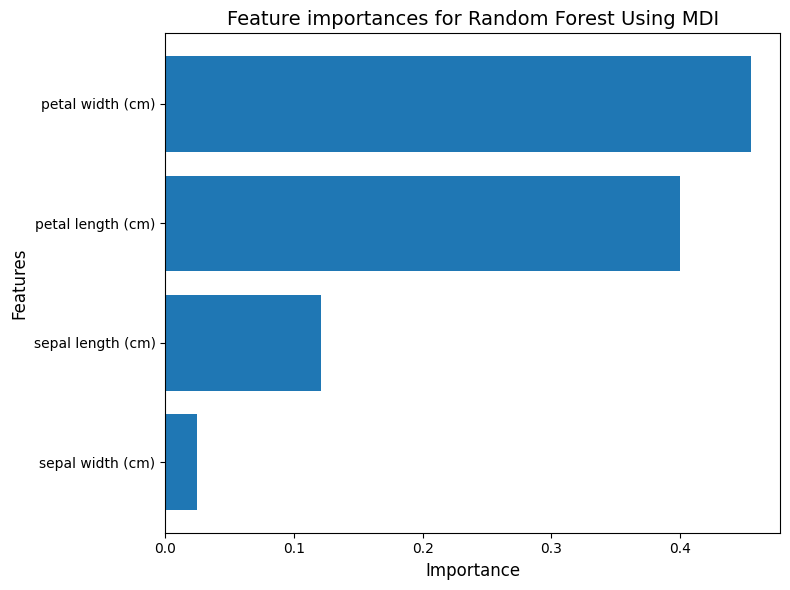


NEW FLOWER PREDICTION
Sepal Length : 5.1 cm
Sepal Width  : 3.5 cm
Petal Length : 1.4 cm
Petal Width  : 0.2 cm

Predicted Species: Iris-setosa


In [5]:
# IRIS FLOWER CLASSIFICATION USING RANDOM FOREST

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# Step 2: Load Iris Dataset
df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")

print("IRIS DATASET")
print("============")
print(df.head())

# Step 3: Dataset Information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# Step 4: Remove Id Column
df = df.drop("Id", axis=1)

# Rename columns for easier use
df = df.rename(columns={
    "SepalLengthCm": "sepal length (cm)",
    "SepalWidthCm": "sepal width (cm)",
    "PetalLengthCm": "petal length (cm)",
    "PetalWidthCm": "petal width (cm)"
})

print("\nDataset after preprocessing:")
print(df.head())

# Step 5: Separate Features and Target
X = df.drop("Species", axis=1)
y = df["Species"]

# Step 6: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# Step 7: Create Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Step 8: Train Model
model.fit(X_train, y_train)

print("\nRandom Forest Model Trained Successfully!")

# Step 9: Prediction
y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

# Step 10: Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL ACCURACY")
print("==============================")

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

# Step 11: Classification Report
print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(classification_report(y_test, y_pred))

# Step 12: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\n==============================")
print("CONFUSION MATRIX")
print("==============================")

print(cm)

# Create confusion matrix graph
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["setosa", "versicolor", "virginica"],
    yticklabels=["setosa", "versicolor", "virginica"],
    cbar=True
)

plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.title("Confusion Matrix - Random Forest", fontsize=14)

plt.tight_layout()
plt.show()

# Step 13: Feature Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort from smallest to largest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(feature_importance)

# Step 14: Feature Importance Graph
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title(
    "Feature importances for Random Forest Using MDI",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Step 15: Predict a New Flower
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = model.predict(new_flower)

print("\n==============================")
print("NEW FLOWER PREDICTION")
print("==============================")

print("Sepal Length : 5.1 cm")
print("Sepal Width  : 3.5 cm")
print("Petal Length : 1.4 cm")
print("Petal Width  : 0.2 cm")

print("\nPredicted Species:", prediction[0])